#  Light ML workflow for image classification
In this notebook we will go through a light ML workflow for image classification using the simulated data that we generated in the previous notebooks. Wew generated images based on a tibial somatosensory stimulation paradigm. We have the ERP image (time domain feautres), as well as the time frequency plots (ITPC). The overarching goal is twofold:

1) To test whether ERP or ITPC or a combination of both can be used to classify weather the stimulation response is "normal", "abnormal", or "abolished".
2)  To compare the performance of different models (pre-trained vs. simple CNN) on this classification task.

The ultimate goal is to determine which model and which type of features (ERP vs. ITPC) can best classify the stimulation response, which can have implications for understanding the underlying neural mechanisms and for developing potential clinical applications.


In [33]:
# Import necessary libraries
import os
import math
import random
from typing import Dict, Tuple

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

# reproducibilty settings
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


## chatgpt suggested code for deterministic behaviour
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

# Handling labels and metadata
Here we will turn the condition column in our mapping.csv file into the 3 target classes.

In [34]:
import pandas as pd
from pathlib import Path
import re

df = pd.read_csv("anonimized_simulated_data/mapping.csv")  # or "/mnt/data/mapping.csv" in your environment

# 1) Map conditions -> 3-class labels
def map_condition_to_label(cond: str) -> str:
    c = str(cond).lower().strip()
    # normalize some possible spellings
    c = c.replace("reduced_delayed", "reduced_delayed")  # no-op but keeps intent clear

    if c == "normal_sub":
        return "normal"
    if c == "abolished_sub":
        return "abolished"
    if c in {"delayed_sub", "reduced_sub", "reduced_delayed_sub", "reduced_delayed","reduced_and_delayed"}:
        return "abnormal"

    # If something unexpected appears, force you to notice
    raise ValueError(f"Unknown condition: {cond}")

df["label"] = df["condition"].apply(map_condition_to_label)

# 2) Build file paths (set these to your actual folders)
ERP_DIR  = Path("anonimized_simulated_data/erp_image")   # <-- change
ITPC_DIR = Path("anonimized_simulated_data/itpc_image")  # <-- change
FULL_DIR = Path("anonimized_simulated_data/full_report") # <-- change
df["erp_path"]  = df["anonimized_file_name_erp"].apply(lambda x: str(ERP_DIR / x))
df["itpc_path"] = df["anonimized_file_name_itpc"].apply(lambda x: str(ITPC_DIR / x))
df["full_path"] = df["anonimized_file_name_full_report"].apply(lambda x: str(FULL_DIR / x))

# 3) subject_id: extract the anonymized subject number from filenames like "subject_7279_erp.jpg"
def extract_subject_id(fname: str) -> str:
    m = re.search(r"(subject_\d+)", str(fname).lower())
    return m.group(1) if m else str(fname)

df["subject_id"] = df["anonimized_file_name_erp"].apply(extract_subject_id)

# 4) sample_id: unique per row
df["sample_id"] = df.index.astype(str)

# 5) Final metadata (what your ML pipeline wants)
meta = df[["sample_id", "subject_id", "label", "erp_path", "itpc_path","full_path"]].copy()

# Optional: integer targets
class_names = ["normal", "abnormal", "abolished"]
label_to_idx = {c:i for i,c in enumerate(class_names)}
meta["y"] = meta["label"].map(label_to_idx)

meta.head()
print(meta.__class__)
# See class counts after merging delayed/reduced into abnormal
meta["label"].value_counts()
# should show something like:
# abnormal      300
# normal        300
# abolished     300

<class 'pandas.DataFrame'>


label
abnormal     1500
abolished     500
normal        500
Name: count, dtype: int64

Now we do train/val/ test splotting by group.

In [35]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # we use GroupShuffleSplit to ensure that all samples from the same subject_id end up in the same split (train, val, or test)
train_idx, test_idx = next(gss.split(meta, groups=meta["subject_id"]))
train_df = meta.iloc[train_idx].reset_index(drop=True)
test_df = meta.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, val_idx = next(gss2.split(train_df, groups=train_df["subject_id"]))
train_df2  = train_df.iloc[train_idx2].reset_index(drop=True)
val_df = train_df.iloc[val_idx].reset_index(drop=True)
train_df = train_df2

# check splits
print("Train label distribution:\n", train_df["label"].value_counts())
print("\nVal label distribution:\n", val_df["label"].value_counts())
print("\nTest label distribution:\n", test_df["label"].value_counts())

# add numbers to check that there are no overlaps in subject_id between splits
print("\nUnique subject_ids in train:", train_df["subject_id"].nunique())
print("Unique subject_ids in val:", val_df["subject_id"].nunique())
print("Unique subject_ids in test:", test_df["subject_id"].nunique())
print("\nTotal unique subject_ids:", meta["subject_id"].nunique())

Train label distribution:
 label
abnormal     953
abolished    328
normal       319
Name: count, dtype: int64

Val label distribution:
 label
abnormal     242
abolished     80
normal        78
Name: count, dtype: int64

Test label distribution:
 label
abnormal     305
normal       103
abolished     92
Name: count, dtype: int64

Unique subject_ids in train: 1600
Unique subject_ids in val: 400
Unique subject_ids in test: 500

Total unique subject_ids: 2500


# Images into tensors
We already made sure our inputs are constant sizes, and removed labels/axis from them  when we generated them but we might want to transform them into consistent formats to match the inputs of the models being used. For example, if we use a pre-trained ResNet, it expects 3-channel RGB images of size 224x224. If our ERP and ITPC images are grayscale and of different sizes, we will need to convert them to the expected format. We can do this using torchvision transforms. We will create a custom dataset class that loads the images, applies the necessary transformations. First we look at some examples of inputs.


(3000, 1000, 3)
(2000, 2000, 3)


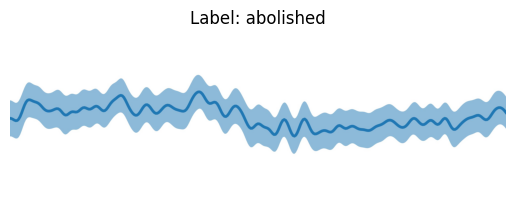

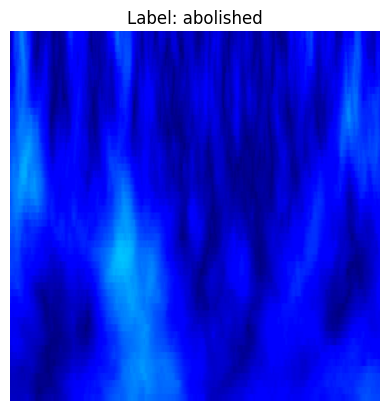

In [36]:
# determine image sizes and channels
from PIL import Image
def get_image_info(path: str) -> Tuple[int, int, int]:
    with Image.open(path) as img:
        return img.size[0], img.size[1], len(img.getbands())
# check a few images
print(get_image_info(train_df["erp_path"].iloc[0]))  # e.g. (300, 200, 1) for a grayscale image of size 300x200
print(get_image_info(train_df["itpc_path"].iloc[0])) # e.g. (300, 200, 1) for a grayscale image of size 300x200

# display an example ERP image
img = Image.open(train_df["erp_path"].iloc[0])
plt.imshow(img, cmap="gray")
plt.title(f"Label: {train_df['label'].iloc[0]}")
plt.axis("off")
plt.show()

# display an example ITPC image
img = Image.open(train_df["itpc_path"].iloc[0])
plt.imshow(img, cmap="gray")
plt.title(f"Label: {train_df['label'].iloc[0]}")
plt.axis("off")
plt.show()


In [37]:
# Here we will define the transforms to get the data into the models. for now lets assume an IMG_SIZE of 224. Depending on the model I might need to change this. If looking at the ERP, we can convert to grayscale and test inputs as 1-channels. For ITPC, we keep them as a 3-channel RGB (model dependent). If we want to use both ERP and ITPC together, we will need to make sure they have the same number of channels and the same size. For simplicity, we can convert both to 3-channel RGB and resize them to 224x224. This way we can easily feed them into a pre-trained ResNet or a simple CNN. We can also experiment with different sizes and channels later on. As a final point, we need to normalize to have pixel values in the same range as the pre-trained models. For now lets normalize to [-1,1].

IMG_SIZE = 224
# train transform for ERP and ITPC (both converted to 3-channel RGB and resized to 224x224)
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # resize to expected size
    #transforms.RandomCrop((IMG_SIZE, IMG_SIZE), padding=4, padding_mode="edge"), # very light augmentation. might try not doing any but for now this is ok. propably will do a testing grid later with different augmentations. For now because of the very deterministic generation of images, we are not doing any.
    #transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.02, hue=0.0),
    #transforms.Grayscale(num_output_channels=3),  # convert to 3-channel grayscale (if needed)
    transforms.ToTensor(),  # convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # normalize to [-1, 1]. actually changed to ImageNet stats since we are using pretained models.
])

# eval and test transforms (same as train but without data augmentation)
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),# convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])



# Dataset class definition
Now we will define a custom dataset class that can load the ERP and ITPC images and both images.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31064308..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


Example row:
 sample_id                                                   606
subject_id                                         subject_8346
label                                                  abnormal
erp_path      anonimized_simulated_data\erp_image\subject_83...
itpc_path     anonimized_simulated_data\itpc_image\subject_8...
full_path     anonimized_simulated_data\full_report\subject_...
y                                                             1
Name: 400, dtype: object

ERP image tensor shape: torch.Size([3, 224, 224])
ITPC image tensor shape: torch.Size([3, 224, 224])
Both ERP and ITPC image tensor shapes: torch.Size([3, 224, 224]) torch.Size([3, 224, 224])
Label: 1 1 1


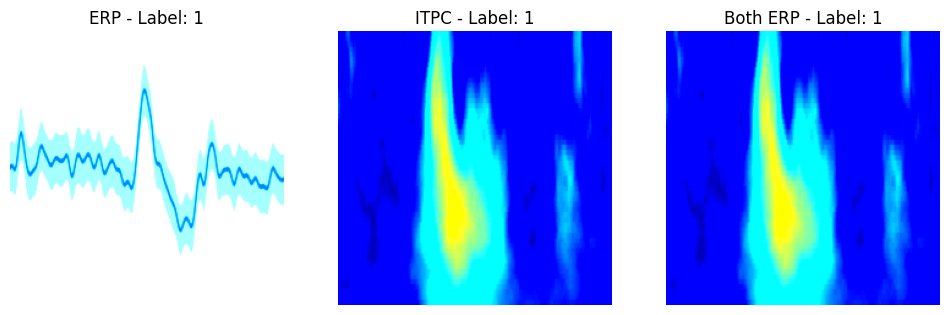

In [38]:
def load_image(path):
    return Image.open(path).convert("RGB")

class StimDataset(Dataset):
    def __init__(self, df, mode="erp", transform=None):
        """
        mode: 'erp', 'itpc', 'both'
        """
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y = int(row["y"])

        if self.mode == "erp":
            img = load_image(row["erp_path"])
            x = self.transform(img) if self.transform else img
            return x, y

        if self.mode == "itpc":
            img = load_image(row["itpc_path"])
            x = self.transform(img) if self.transform else img
            return x, y

        if self.mode == "both":
            img1 = load_image(row["erp_path"])
            img2 = load_image(row["itpc_path"])
            x1 = self.transform(img1) if self.transform else img1
            x2 = self.transform(img2) if self.transform else img2
            return (x1, x2), y

        raise ValueError("mode must be one of: 'erp', 'itpc', 'both'")

# testing the dataset
ex_id = 400
example_row = train_df.iloc[ex_id]
print("Example row:\n", example_row)
dataset_erp = StimDataset(train_df, mode="erp", transform=train_tfms)
dataset_itpc = StimDataset(train_df, mode="itpc", transform=train_tfms)
dataset_both = StimDataset(train_df, mode="both", transform=train_tfms)
x_erp, y_erp = dataset_erp[ex_id]
x_itpc, y_itpc = dataset_itpc[ex_id]
(x_both_erp, x_both_itpc), y_both = dataset_both[ex_id]
print("\nERP image tensor shape:", x_erp.shape)  # should be (3, 224, 224)
print("ITPC image tensor shape:", x_itpc.shape)  # should be (3, 224, 224)
print("Both ERP and ITPC image tensor shapes:", x_both_erp.shape, x_both_itpc.shape)  # should both be (3, 224, 224)
print("Label:", y_erp, y_itpc, y_both)  # should all be the same

# display the images from the dataset to check transforms
def show_image(tensor_img, title=""):
    img = tensor_img.permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5  # unnormalize
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
show_image(x_erp, title=f"ERP - Label: {y_erp}")
plt.subplot(1, 3, 2)
show_image(x_itpc, title=f"ITPC - Label: {y_itpc}")
plt.subplot(1, 3, 3)
show_image(x_both_itpc, title=f"Both ERP - Label: {y_both}")
plt.show()

# Class imbalance handling
Before we start training, we should check if there is any class imbalance in our dataset. If there are, we can deal with them witht eh WeightedRandomSampler in the DataLoader. This will ensure that during training, the model sees a balanced number of samples from each class, which can help improve performance on minority classes.

In [39]:
counts = train_df["y"].value_counts()
class_weights = (1.0 / counts)

sample_weights = torch.tensor(
    class_weights.reindex(train_df["y"]).to_numpy(),
    dtype=torch.double
)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# check the weights
print("Class counts:\n", counts)
print("\nClass weights:\n", class_weights)
print("\nSample weights:\n", sample_weights[:10])  # print first 10

# no class imbalance in our dataset since we generated it with equal samples per class, but this is how you would handle it if there was an imbalance. We will use the sampler in the DataLoader for training.

Class counts:
 y
1    953
2    328
0    319
Name: count, dtype: int64

Class weights:
 y
1    0.001049
2    0.003049
0    0.003135
Name: count, dtype: float64

Sample weights:
 tensor([0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030,
        0.0030], dtype=torch.float64)


# Dataloaders
Here we define the dataloaders for training, validation and testing.

In [40]:
BATCH_SIZE = 48

def make_loaders(mode):
    train_ds = StimDataset(train_df, mode=mode, transform=train_tfms)
    val_ds   = StimDataset(val_df, mode=mode, transform=eval_tfms)
    test_ds  = StimDataset(test_df, mode=mode, transform=eval_tfms)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=False)
    val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    return train_dl, val_dl, test_dl


# Model definitions - simple CNN vs. Resnet18 vs. EfficientNetV2
Here we will define the models we want to use for classification. We will start with a simpleCNN and ResNet18.

In [41]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 3 input channels, 16 output channels, kernel size of 3, padding of 1.
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)), # adaptive avgpool.
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.classifier(x)


def _set_bn_eval(module: nn.Module):
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
            m.eval()

def make_resnet18(num_classes=3, freeze_backbone=True):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # load pretrained weights

    # Replace head first
    m.fc = nn.Linear(m.fc.in_features, num_classes)

    if freeze_backbone: # freezing for transfer learning
        # Freeze everything
        for p in m.parameters():
            p.requires_grad = False
        # Unfreeze head
        for p in m.fc.parameters():
            p.requires_grad = True
        # Freeze BN running stats
        _set_bn_eval(m)

    # Sanity check
    num_trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"ResNet18 freeze_backbone={freeze_backbone} trainable params: {num_trainable:,}")
    return m



def make_effnetv2_single(num_classes=3, pretrained=True, freeze_backbone=True):
    weights = models.EfficientNet_V2_S_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_v2_s(weights=weights)  # <-- correct name

    # Replace head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        # Freeze all params
        for p in model.parameters():
            p.requires_grad = False
        # Unfreeze classifier params
        for p in model.classifier.parameters():
            p.requires_grad = True

        # Optional: freeze BN running stats (EffNet has BN too)
        for m in model.modules():
            if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
                m.eval()

    return model

# helper to see the trainable params
def count_trainable(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Trainable: {trainable:,} / Total: {total:,}")



# Two input late fusion models
Here we will define a simple late fusion CNN and a late fusion resnet18. For the simple one, since we are training them, I defined each branch separately so that they do not share the same weights. These will allow for combining both ERP and ITPC features for classification. The late fusion approach means that we will process the ERP and ITPC images separately through their own feature extractors, and then combine the extracted features before the final classification layer.

In [42]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

class SimpleFusionCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.erp_branch = SimpleCNN(num_classes=128)
        self.itpc_branch = SimpleCNN(num_classes=128)

        self.erp_branch.classifier = nn.Identity()
        self.itpc_branch.classifier = nn.Identity()

        self.fc = nn.Linear(128 + 128, num_classes)

    def forward(self, x_erp, x_itpc):
        e1 = self.erp_branch(x_erp)   # (B,128)
        e2 = self.itpc_branch(x_itpc) # (B,128)
        z = torch.cat([e1, e2], dim=1)
        return self.fc(z)





class ResNetFusion(nn.Module):
    def __init__(self, num_classes=3, freeze_backbone=True):
        super().__init__()
        self.erp = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.itpc = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # remove final classifier, keep embedding
        erp_dim = self.erp.fc.in_features
        itpc_dim = self.itpc.fc.in_features
        self.erp.fc = nn.Identity()
        self.itpc.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(erp_dim + itpc_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        if freeze_backbone:
            for p in self.erp.parameters():
                p.requires_grad = False
            for p in self.itpc.parameters():
                p.requires_grad = False

            # keep BN running stats fixed when backbone is frozen
            self._set_bn_eval(self.erp)
            self._set_bn_eval(self.itpc)

            # make sure head is trainable
            for p in self.head.parameters():
                p.requires_grad = True

    def forward(self, x1, x2):
        e1 = self.erp(x1)
        e2 = self.itpc(x2)
        return self.head(torch.cat([e1, e2], dim=1))

    @staticmethod
    def _set_bn_eval(module: nn.Module):
        for m in module.modules():
            if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
                m.eval()




class EffNetV2LateFusionTwoTowers(nn.Module):
    def __init__(
            self,
            num_classes: int = 3,
            pretrained: bool = True,
            hidden: int = 512, # size of the hidden layer in the fusion head
            freeze_backbone: bool = True,
            freeze_bn_stats: bool = True,  # recommended when freezing backbone
    ):
        super().__init__()
        weights = EfficientNet_V2_S_Weights.DEFAULT if pretrained else None

        erp_net = efficientnet_v2_s(weights=weights)
        itpc_net = efficientnet_v2_s(weights=weights)

        self.erp_features = erp_net.features # feature extractor part of the network (everything except the classifier)
        self.itpc_features = itpc_net.features
        self.erp_pool = erp_net.avgpool # pooling layer. average pooling.
        self.itpc_pool = itpc_net.avgpool

        feat_dim = erp_net.classifier[1].in_features  # should be 1280 for effnetv2_s

        self.fusion_head = nn.Sequential(
            nn.Linear(feat_dim * 2, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(hidden, num_classes),
        )

        if freeze_backbone:
            for p in self.erp_features.parameters():
                p.requires_grad = False
            for p in self.itpc_features.parameters():
                p.requires_grad = False

            # If you're freezing, also freezing BN running stats is often safer
            if freeze_bn_stats:
                self._set_bn_eval(self.erp_features)
                self._set_bn_eval(self.itpc_features)

        # explicitly make sure head is trainable
        for p in self.fusion_head.parameters():
            p.requires_grad = True

    @staticmethod
    def _set_bn_eval(module: nn.Module):
        for m in module.modules():
            if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
                m.eval()

    def encode_erp(self, x: torch.Tensor) -> torch.Tensor:
        x = self.erp_features(x)
        x = self.erp_pool(x)
        return torch.flatten(x, 1)

    def encode_itpc(self, x: torch.Tensor) -> torch.Tensor:
        x = self.itpc_features(x)
        x = self.itpc_pool(x)
        return torch.flatten(x, 1)

    def forward(self, erp: torch.Tensor, itpc: torch.Tensor) -> torch.Tensor:
        f_erp = self.encode_erp(erp)
        f_itpc = self.encode_itpc(itpc)
        fused = torch.cat([f_erp, f_itpc], dim=1)
        return self.fusion_head(fused)



# Defining the training loop
Here we have an adaptable training loop (works for single and dual input models) tha takes the model, the dataloader, and the optimizers and trains the model for one epoch. We will also define a function for evaluating the model on the validation and test sets.

In [43]:
import numpy as np
import torch
import torch.nn.functional as F

def run_epoch(model, dl, device, optimizer=None, grad_clip=None, return_probs=False):
    train = optimizer is not None
    print(f"{'Training' if train else 'Evaluating'} for one epoch...")

    model.train() if train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_y = [], []
    all_probs = []  # NEW

    for bi, batch in enumerate(dl, start=1):
        print(f"Processing batch {bi}/{len(dl)}...")

        # ---- unpack batch robustly ----
        x1 = x2 = None

        if isinstance(batch, (list, tuple)):
            if len(batch) == 2:
                x, y = batch
                if isinstance(x, (list, tuple)) and len(x) == 2:
                    x1, x2 = x
                elif isinstance(x, dict) and "itpc" in x and "erp" in x:
                    x1, x2 = x["itpc"], x["erp"]
                else:
                    x_single = x
            elif len(batch) == 3:
                x1, x2, y = batch
            else:
                raise ValueError(f"Unexpected batch length: {len(batch)}")
        else:
            raise ValueError(f"Unexpected batch type: {type(batch)}")

        # ---- forward/loss ----
        with torch.set_grad_enabled(train):
            y = y.to(device)

            if x1 is not None and x2 is not None:
                x1 = x1.to(device)
                x2 = x2.to(device)
                logits = model(x1, x2)
            else:
                x_single = x_single.to(device)
                logits = model(x_single)

            loss = F.cross_entropy(logits, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

        # ---- metrics ----
        bs = y.size(0)
        total_loss += loss.item() * bs
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += bs

        all_preds.append(preds.detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy())

        if return_probs:
            probs = torch.softmax(logits, dim=1)         # NEW
            all_probs.append(probs.detach().cpu().numpy())

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)

    all_preds = np.concatenate(all_preds) if all_preds else np.array([])
    all_y = np.concatenate(all_y) if all_y else np.array([])

    print(f"{'Train' if train else 'Eval'} - Loss: {avg_loss:.4f}, Acc: {acc:.3f}")

    if return_probs:
        all_probs = np.concatenate(all_probs) if all_probs else np.array([])
        return avg_loss, acc, all_y, all_preds, all_probs

    return avg_loss, acc, all_y, all_preds

# Fit with early stopping
Now we will define a function to fit the model for multiple epochs, with early stopping based on validation loss. We will also keep track of the best model based on validation performance.

In [44]:
def fit(model, train_dl, val_dl, lr=1e-3, epochs=15, patience=3):
    model.to(device)

    # Only optimize trainable params
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=lr)

    best_val = float("inf")
    best_state = None
    bad = 0

    hist = []
    for ep in range(1, epochs+1):
        print(f"Epoch {ep}/{epochs} starting...")
        tr_loss, tr_acc, _, _ = run_epoch(model, train_dl, device=device, optimizer=optimizer)
        va_loss, va_acc, _, _ = run_epoch(model, val_dl, device=device, optimizer=None)

        hist.append({"epoch": ep, "tr_loss": tr_loss, "tr_acc": tr_acc,
                     "va_loss": va_loss, "va_acc": va_acc})

        print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")

        if va_loss < best_val - 1e-4:
            best_val = va_loss
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return pd.DataFrame(hist), model


# Test eval and confusion matrix
Finally, we will define a function to evaluate the best model on the test set and compute the classification report and confusion matrix.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

def evaluate(model, test_dl, class_names):
    loss, acc, y_true, y_pred, y_score = run_epoch(
        model, test_dl, device=device, optimizer=None, return_probs=True
    )
    print(f"Test loss: {loss:.4f} | Test acc: {acc:.3f}\n")

    print(classification_report(y_true, y_pred, target_names=class_names))

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,5))
    im = plt.imshow(cm, cmap="magma", vmin=0)
    plt.title("Confusion Matrix for " + model.__class__.__name__)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # ---- Multiclass ROC (One-vs-Rest) ----
    n_classes = len(class_names)
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(6,6))
    aucs = []
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    # micro-average (optional, but fine for 5 balanced classes)
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, linestyle="--", label=f"micro (AUC={auc_micro:.3f})")

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC (OvR)")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    macro_auc = float(np.mean(aucs))

    return {"loss": loss, "acc": acc, "cm": cm, "macro_auc": macro_auc, "micro_auc": float(auc_micro)}

# EXPERIMENTS! HOW EXCITING!
Now we can run our experiments by training the different models (SimpleCNN, ResNet18, SimpleFusionCNN, ResNetFusion) on the different input types (ERP, ITPC, Both) and evaluating their performance on the test set. We can then compare the results to see which model and which input type performs best for classifying the stimulation response. We can also analyze the confusion matrices to see if there are specific classes that are more often confused with each other. This will give us insights into which features (ERP vs. ITPC) are more informative for the classification task and how well the models are able to learn from those features.

First let us define an experiment runner

In [46]:
def run_experiment(mode, model_kind):
    train_dl, val_dl, test_dl = make_loaders(mode)

    if mode in ["erp", "itpc"]:
        if model_kind == "simple":
            model = SimpleCNN(num_classes=3)
        elif model_kind == "resnet":
            model = make_resnet18(num_classes=3, freeze_backbone=True)
        elif model_kind == "effnet":
            model = make_effnetv2_single(num_classes=3, freeze_backbone=True)
        else:
            raise ValueError("model_kind must be 'simple' or 'pretrained'")

    elif mode == "both":
        if model_kind == "simple":
            model = SimpleFusionCNN(num_classes=3)
        elif model_kind == "resnet":
            model = ResNetFusion(num_classes=3, freeze_backbone=True)
        elif model_kind == "effnet":
            model = EffNetV2LateFusionTwoTowers(num_classes=3, freeze_backbone=True)
        else:
            raise ValueError("model_kind must be 'simple' or 'pretrained'")
    else:
        raise ValueError("mode must be 'erp', 'itpc', 'both'")

    print(f"Running experiment with mode={mode} and model_kind={model_kind}...")
    print(f"Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    print("Starting training...")
    hist, model = fit(model, train_dl, val_dl, lr=1e-3, epochs=25, patience=7)
    print("Training completed. Evaluating on test set...")
    metrics = evaluate(model, test_dl, class_names)
    print(f" Evaluation done. Test set results:\n{metrics}")

    out = {
        "mode": mode,
        "model": model_kind,
        "test_acc": metrics["acc"],
        "test_loss": metrics["loss"],
        "macro_auc": metrics.get("macro_auc"),
        "micro_auc": metrics.get("micro_auc"),
    }
    return out, hist



# Experiment grid
We will take erp, itpc, and both as input modes, and simple vs. pretrained as model kinds, and run the experiments for all combinations.


MODE=erp | MODEL=effnet
Running experiment with mode=erp and model_kind=effnet...
Number of trainable parameters: 3843
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Processing batch 22/34...
Processing batch 23/34...
Processing batch 24/34...
Processing batch 25/34...
Processing batch 26/34...
Processing batch 27/34...
Processing batch 28/34...
Processing batch 29/34...
Processing batch 30/34...
Processing batch 31/34...
Processing ba

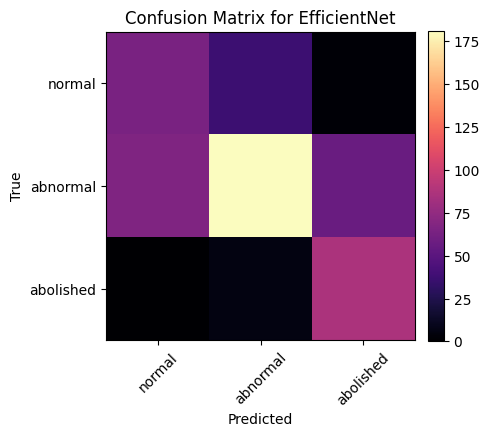

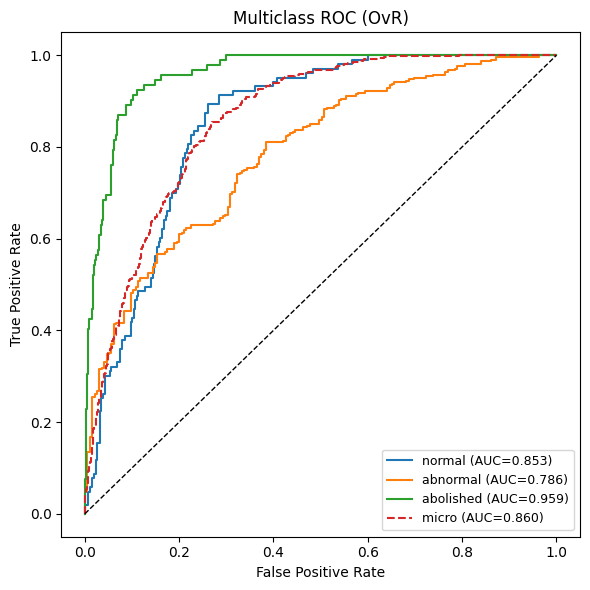

 Evaluation done. Test set results:
{'loss': 0.676545527458191, 'acc': 0.662, 'cm': array([[ 64,  37,   2],
       [ 67, 181,  57],
       [  0,   6,  86]]), 'macro_auc': 0.8660271898834965, 'micro_auc': 0.86031}

MODE=erp | MODEL=resnet
ResNet18 freeze_backbone=True trainable params: 1,539
Running experiment with mode=erp and model_kind=resnet...
Number of trainable parameters: 1539
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Proces

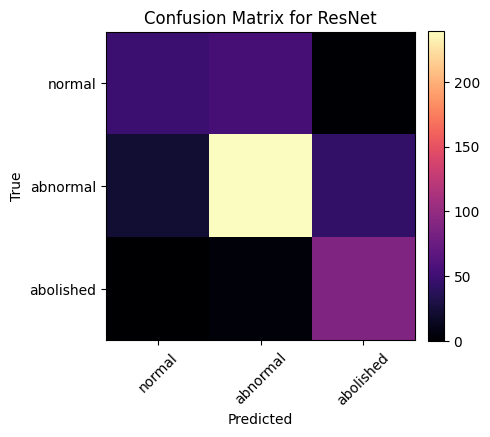

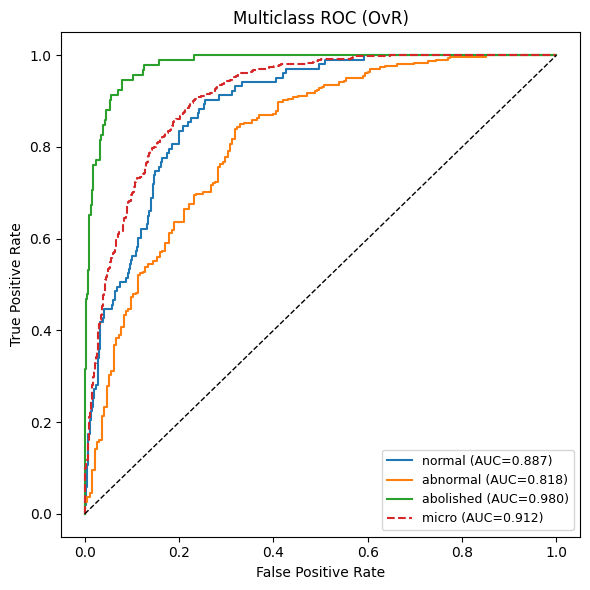

 Evaluation done. Test set results:
{'loss': 0.5407427687644959, 'acc': 0.75, 'cm': array([[ 48,  54,   1],
       [ 23, 239,  43],
       [  0,   4,  88]]), 'macro_auc': 0.8951503698029747, 'micro_auc': 0.911588}

MODE=erp | MODEL=simple
Running experiment with mode=erp and model_kind=simple...
Number of trainable parameters: 97827
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Processing batch 22/34...
Processing batch 23/34...
Proces

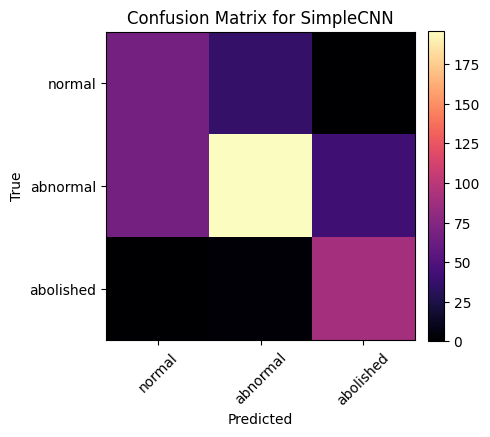

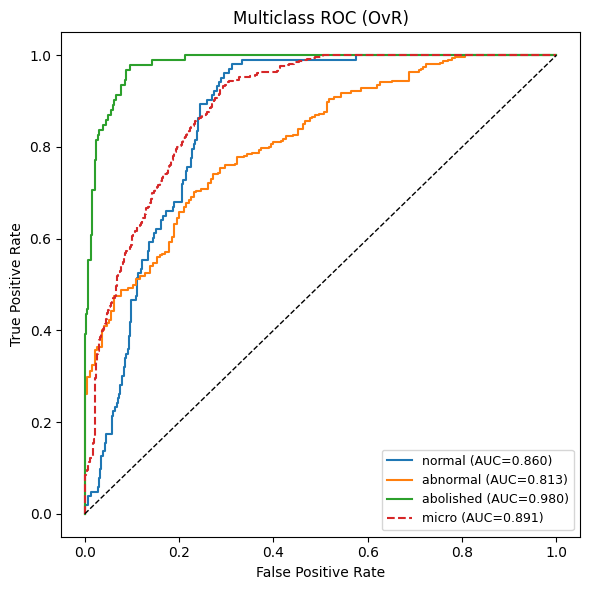

 Evaluation done. Test set results:
{'loss': 0.5798301653861999, 'acc': 0.706, 'cm': array([[ 67,  36,   0],
       [ 67, 196,  42],
       [  0,   2,  90]]), 'macro_auc': 0.8843412922626642, 'micro_auc': 0.890514}

MODE=itpc | MODEL=effnet
Running experiment with mode=itpc and model_kind=effnet...
Number of trainable parameters: 3843
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Processing batch 22/34...
Processing batch 23/34...
Proc

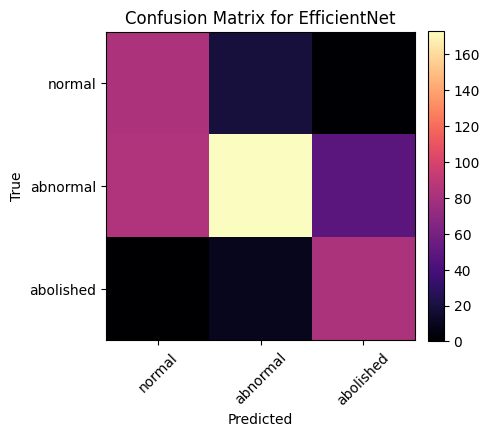

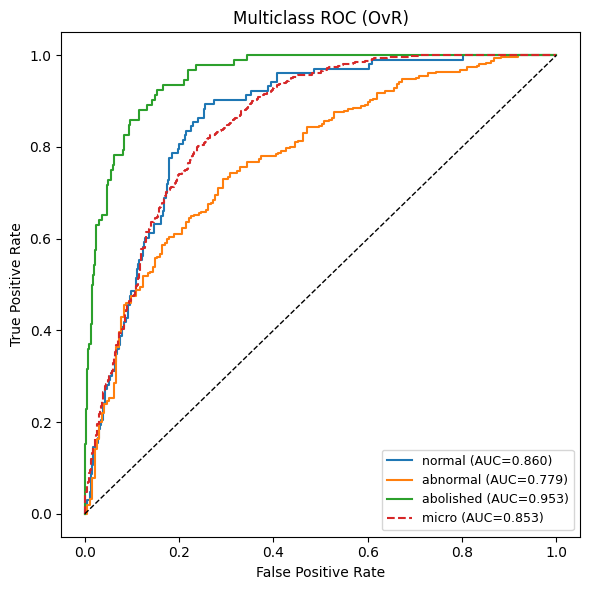

 Evaluation done. Test set results:
{'loss': 0.6931999778747558, 'acc': 0.676, 'cm': array([[ 83,  19,   1],
       [ 84, 173,  48],
       [  0,  10,  82]]), 'macro_auc': 0.8637981885812369, 'micro_auc': 0.8525319999999998}

MODE=itpc | MODEL=resnet
ResNet18 freeze_backbone=True trainable params: 1,539
Running experiment with mode=itpc and model_kind=resnet...
Number of trainable parameters: 1539
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 2

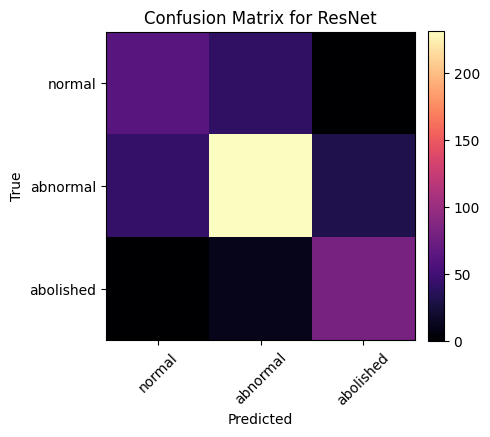

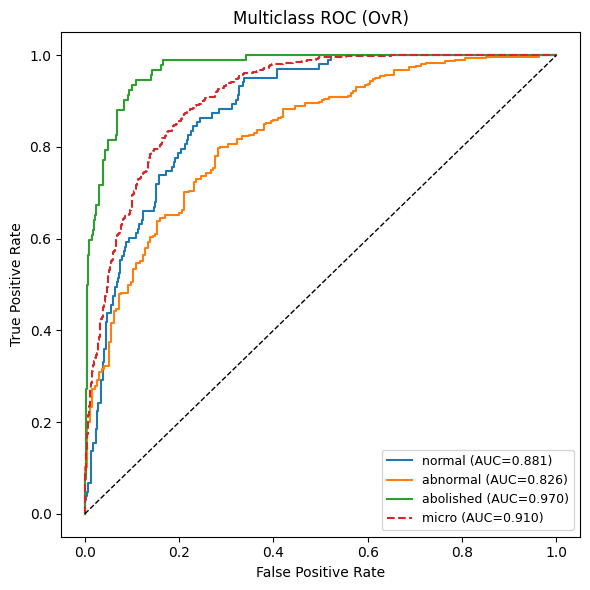

 Evaluation done. Test set results:
{'loss': 0.5434615950584412, 'acc': 0.75, 'cm': array([[ 63,  40,   0],
       [ 43, 231,  31],
       [  0,  11,  81]]), 'macro_auc': 0.8924724274885603, 'micro_auc': 0.910332}

MODE=itpc | MODEL=simple
Running experiment with mode=itpc and model_kind=simple...
Number of trainable parameters: 97827
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Processing batch 22/34...
Processing batch 23/34...
Proc

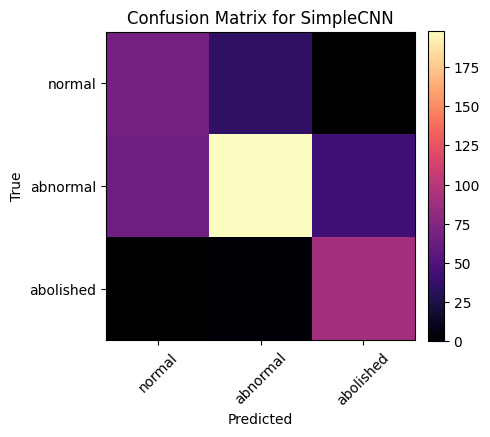

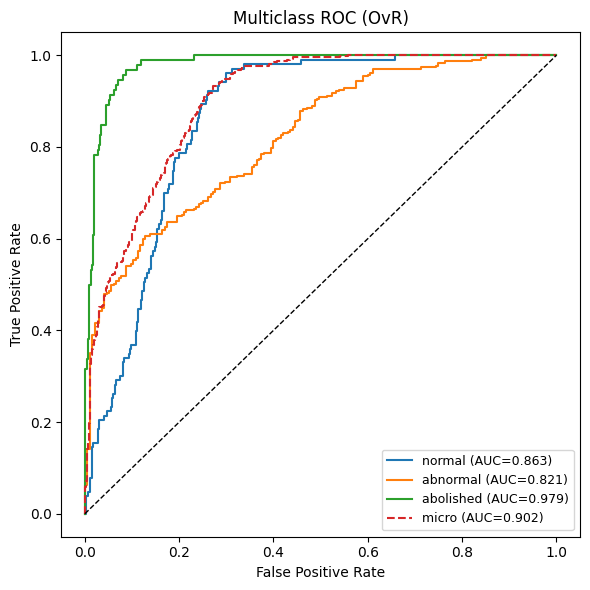

 Evaluation done. Test set results:
{'loss': 0.5434470765590668, 'acc': 0.71, 'cm': array([[ 68,  35,   0],
       [ 65, 198,  42],
       [  0,   3,  89]]), 'macro_auc': 0.8877440186223198, 'micro_auc': 0.902014}

MODE=both | MODEL=effnet
Running experiment with mode=both and model_kind=effnet...
Number of trainable parameters: 1312771
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Processing batch 22/34...
Processing batch 23/34...
Pr

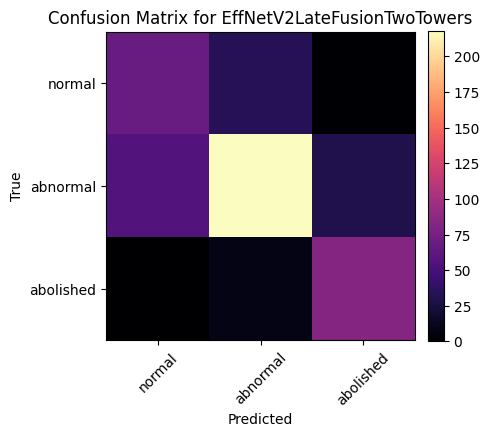

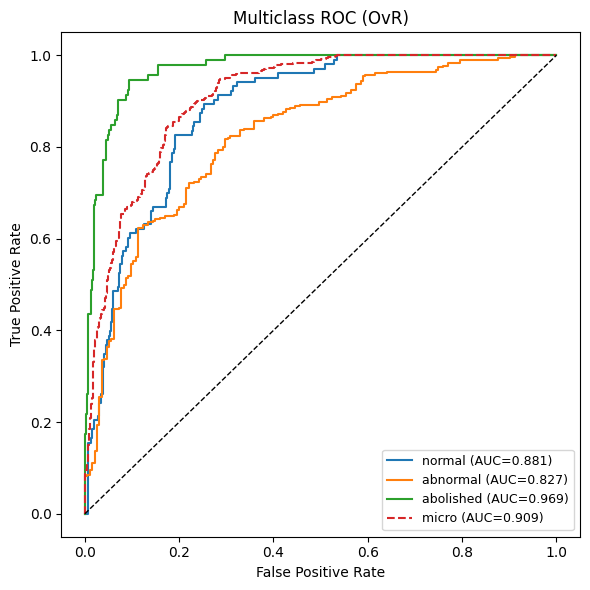

 Evaluation done. Test set results:
{'loss': 0.5546629962921142, 'acc': 0.738, 'cm': array([[ 68,  34,   1],
       [ 57, 218,  30],
       [  0,   9,  83]]), 'macro_auc': 0.8920934888280038, 'micro_auc': 0.90944}

MODE=both | MODEL=resnet
Running experiment with mode=both and model_kind=resnet...
Number of trainable parameters: 131587
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Processing batch 22/34...
Processing batch 23/34...
Pro

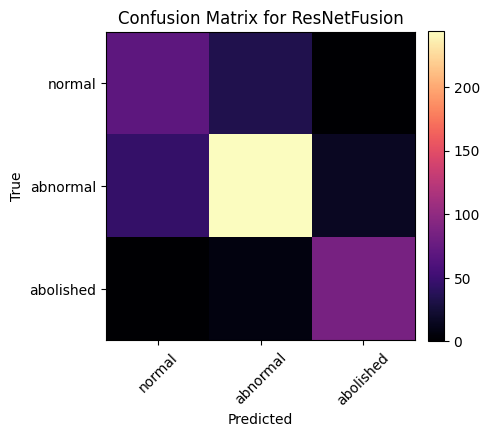

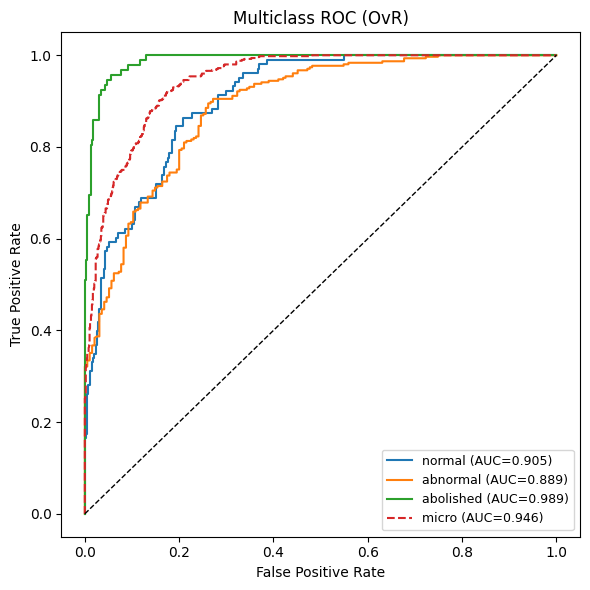

 Evaluation done. Test set results:
{'loss': 0.41901615989208224, 'acc': 0.796, 'cm': array([[ 69,  34,   0],
       [ 45, 244,  16],
       [  0,   7,  85]]), 'macro_auc': 0.9275093639981803, 'micro_auc': 0.945697}

MODE=both | MODEL=simple
Running experiment with mode=both and model_kind=simple...
Number of trainable parameters: 195651
Starting training...
Epoch 1/25 starting...
Training for one epoch...
Processing batch 1/34...
Processing batch 2/34...
Processing batch 3/34...
Processing batch 4/34...
Processing batch 5/34...
Processing batch 6/34...
Processing batch 7/34...
Processing batch 8/34...
Processing batch 9/34...
Processing batch 10/34...
Processing batch 11/34...
Processing batch 12/34...
Processing batch 13/34...
Processing batch 14/34...
Processing batch 15/34...
Processing batch 16/34...
Processing batch 17/34...
Processing batch 18/34...
Processing batch 19/34...
Processing batch 20/34...
Processing batch 21/34...
Processing batch 22/34...
Processing batch 23/34...
P

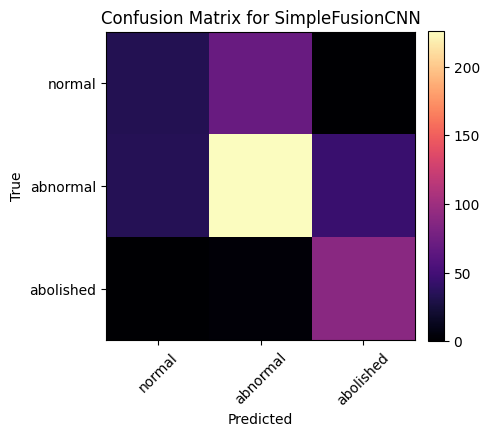

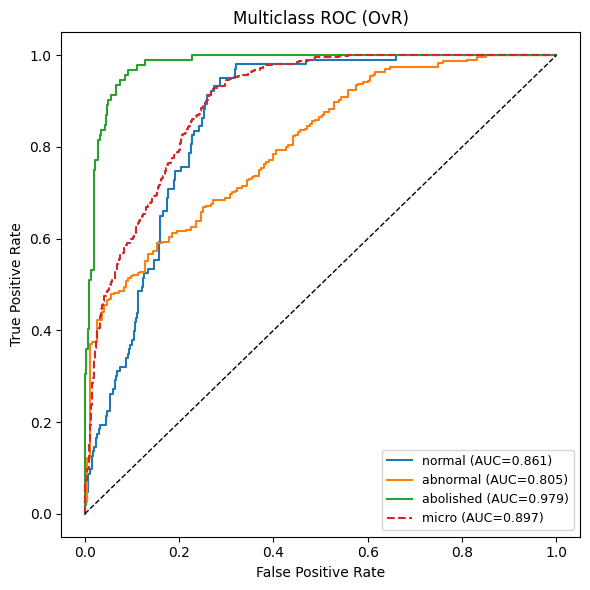

 Evaluation done. Test set results:
{'loss': 0.5594558629989624, 'acc': 0.696, 'cm': array([[ 33,  70,   0],
       [ 34, 226,  45],
       [  0,   3,  89]]), 'macro_auc': 0.8815690844212513, 'micro_auc': 0.897308}


,mode,model,test_acc,test_loss,macro_auc,micro_auc
7,both,resnet,0.796,0.419016,0.927509,0.945697
4,itpc,resnet,0.750,0.543462,0.892472,0.910332
1,erp,resnet,0.750,0.540743,0.895150,0.911588
6,both,effnet,0.738,0.554663,0.892093,0.909440
5,itpc,simple,0.710,0.543447,0.887744,0.902014
2,erp,simple,0.706,0.579830,0.884341,0.890514
8,both,simple,0.696,0.559456,0.881569,0.897308
3,itpc,effnet,0.676,0.693200,0.863798,0.852532
0,erp,effnet,0.662,0.676546,0.866027,0.860310


In [47]:
results = []
hists = {}

for mode in ["erp", "itpc", "both"]:
    for mk in ["effnet","resnet","simple"]:
        print("\n" + "="*80)
        print(f"MODE={mode} | MODEL={mk}")
        out, hist = run_experiment(mode, mk)
        results.append(out)
        hists[(mode, mk)] = hist

res_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
res_df


 Now we can plot the learning curves.

   mode   model  test_acc  test_loss
2   erp  simple  0.805556   0.587751
7  both  resnet  0.794444   0.539074
6  both  effnet  0.788889   0.498422
8  both  simple  0.766667   0.562446
5  itpc  simple  0.766667   0.532269
1   erp  resnet  0.744444   0.559216
4  itpc  resnet  0.722222   0.629256
0   erp  effnet  0.705556   0.571488
3  itpc  effnet  0.672222   0.678183


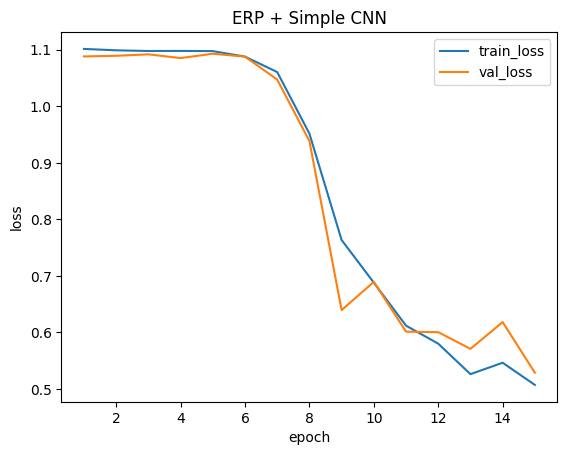

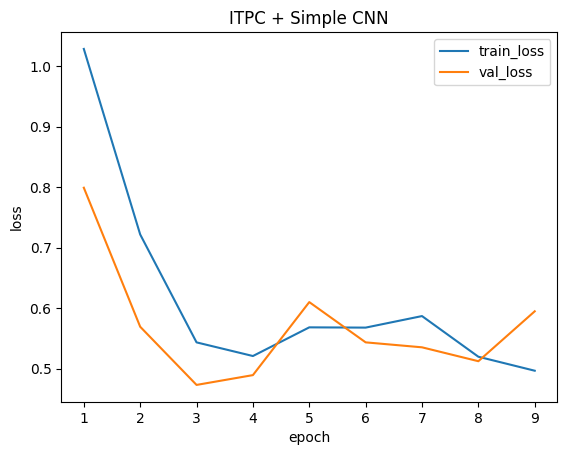

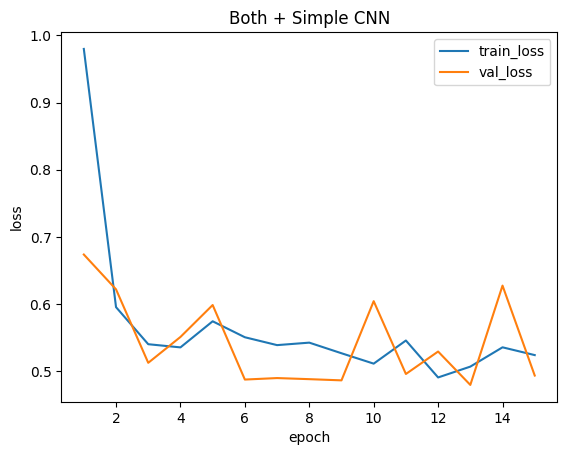

KeyError: ('erp', 'pretrained')

In [61]:
def plot_hist(hist, title=""):
    plt.figure()
    plt.plot(hist["epoch"], hist["tr_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["va_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.show()


res_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
print(res_df)

plot_hist(hists[("erp","simple")], "ERP + Simple CNN")
plot_hist(hists[("itpc","simple")], "ITPC + Simple CNN")
plot_hist(hists[("both","simple")], "Both + Simple CNN")
plot_hist(hists[("erp","pretrained")], "ERP + Pretrained")
plot_hist(hists[("itpc","pretrained")], "ITPC + Pretrained")
plot_hist(hists[("both","pretrained")], "Both + Pretrained")


In [5]:
# store test set labels and images in a separate folder for error analysis
import shutil
ERROR_ANALYSIS_DIR = Path("error_analysis")
#set subfolders for erp, itpc, and full images
ERROR_ANALYSIS_DIR.mkdir(exist_ok=True)
(ERP_ERROR_DIR := ERROR_ANALYSIS_DIR / "erp").mkdir(exist_ok=True)
(ITPC_ERROR_DIR := ERROR_ANALYSIS_DIR / "itpc").mkdir(exist_ok=True)
(FULL_ERROR_DIR := ERROR_ANALYSIS_DIR / "full").mkdir(exist_ok=True)

test_df.to_csv(ERROR_ANALYSIS_DIR / "test_metadata.csv", index=False)
# copy test images to error_analysis folder for easy access
for _, row in test_df.iterrows():
    shutil.copy(row["erp_path"], ERP_ERROR_DIR / Path(row["erp_path"]).name)
    shutil.copy(row["itpc_path"], ITPC_ERROR_DIR / Path(row["itpc_path"]).name)
    shutil.copy(row["full_path"], FULL_ERROR_DIR / Path(row["full_path"]).name)